# Student Dropout and Academic Success Analysis

## Business Question

Which factors are most associated with student dropout, graduation, and academic success?

## Objectives

- Explore the dataset
- Assess data quality
- Identify key trends
- Build an interactive Power BI dashboard
- Publish findings on Substack

In [1]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
predict_students_dropout_and_academic_success = fetch_ucirepo(id=697) 
  
# data (as pandas dataframes) 
X = predict_students_dropout_and_academic_success.data.features 
y = predict_students_dropout_and_academic_success.data.targets 
  
# metadata 
print(predict_students_dropout_and_academic_success.metadata) 
  
# variable information 
print(predict_students_dropout_and_academic_success.variables) 


{'uci_id': 697, 'name': "Predict Students' Dropout and Academic Success", 'repository_url': 'https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success', 'data_url': 'https://archive.ics.uci.edu/static/public/697/data.csv', 'abstract': "A dataset created from a higher education institution (acquired from several disjoint databases) related to students enrolled in different undergraduate degrees, such as agronomy, design, education, nursing, journalism, management, social service, and technologies.\nThe dataset includes information known at the time of student enrollment (academic path, demographics, and social-economic factors) and the students' academic performance at the end of the first and second semesters. \nThe data is used to build classification models to predict students' dropout and academic sucess. The problem is formulated as a three category classification task, in which there is a strong imbalance towards one of the classes.", 'area': 'Social Sc

In [2]:
# Display the first five rows
X.head()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0,0.000000,0,10.8,1.4,1.74
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,0,6,0,0,0.000000,0,10.8,1.4,1.74
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79


In [3]:
# Number of rows and columns
X.shape

(4424, 36)

In [4]:
# Column names
X.columns

Index(['Marital Status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd s

In [5]:
# Data types
X.dtypes

Marital Status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance                          int64
Previous qualification                              int64
Previous qualification (grade)                    float64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Admission grade                                   float64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int64
Gender        

In [6]:
# Missing values
X.isnull().sum()

Marital Status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

In [7]:
y.head()

,Target
0,Dropout
1,Graduate
2,Dropout
3,Graduate
4,Graduate


In [8]:
y.value_counts()

Target  
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

In [9]:
X.describe()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,18.669078,1.727848,8856.642631,0.890823,4.577758,132.613314,1.873192,19.561935,22.275316,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,17.484682,1.313793,2063.566416,0.311897,10.216592,13.188332,6.914514,15.603186,15.343108,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,33.000000,0.000000,1.000000,95.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,9085.000000,1.000000,1.000000,125.000000,1.000000,2.000000,3.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,17.000000,1.000000,9238.000000,1.000000,1.000000,133.100000,1.000000,19.000000,19.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,39.000000,2.000000,9556.000000,1.000000,1.000000,140.000000,1.000000,37.000000,37.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,57.000000,9.000000,9991.000000,1.000000,43.000000,190.000000,109.000000,44.000000,44.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [10]:
import pandas as pd

df = pd.concat([X, y], axis=1)

df.head()

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [11]:
outcome_counts = df["Target"].value_counts()
outcome_percentages = df["Target"].value_counts(normalize=True).mul(100).round(1)

pd.DataFrame({
    "Count": outcome_counts,
    "Percentage": outcome_percentages
})

,Count,Percentage
Target,,
Graduate,2209,49.9
Dropout,1421,32.1
Enrolled,794,17.9


In [12]:
df.groupby("Target")["Age at enrollment"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

,count,mean,median,min,max
Target,,,,,
Dropout,1421,26.07,23.0,18,70
Enrolled,794,22.37,20.0,17,54
Graduate,2209,21.78,19.0,17,62


In [13]:
pd.crosstab(
    df["Scholarship holder"],
    df["Target"],
    normalize="index"
).mul(100).round(1)

Target,Dropout,Enrolled,Graduate
Scholarship holder,,,
0,38.7,20.0,41.3
1,12.2,11.8,76.0


In [14]:
df.groupby("Target")[
    ["Unemployment rate", "Inflation rate", "GDP"]
].mean().round(2)

,Unemployment rate,Inflation rate,GDP
Target,,,
Dropout,11.62,1.28,-0.15
Enrolled,11.27,1.21,0.05
Graduate,11.64,1.20,0.08


In [15]:
variables_to_test = [
    "Tuition fees up to date",
    "Debtor",
    "Curricular units 1st sem (approved)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 2nd sem (grade)"
]

In [16]:
df.groupby("Target")[variables_to_test].mean().round(2)

,Tuition fees up to date,Debtor,Curricular units 1st sem (approved),Curricular units 2nd sem (approved),Curricular units 1st sem (grade),Curricular units 2nd sem (grade)
Target,,,,,,
Dropout,0.68,0.22,2.55,1.94,7.26,5.90
Enrolled,0.95,0.11,4.32,4.06,11.13,11.12
Graduate,0.99,0.05,6.23,6.18,12.64,12.70


In [17]:
pd.crosstab(
    df["Tuition fees up to date"],
    df["Target"],
    normalize="index"
).mul(100).round(1)

Target,Dropout,Enrolled,Graduate
Tuition fees up to date,,,
0,86.6,8.0,5.5
1,24.7,19.3,56.0


In [18]:
pd.crosstab(
    df["Debtor"],
    df["Target"],
    normalize="index"
).mul(100).round(1)

Target,Dropout,Enrolled,Graduate
Debtor,,,
0,28.3,18.0,53.8
1,62.0,17.9,20.1


In [19]:
academic_comparison = df.groupby("Target")[
    [
        "Curricular units 1st sem (approved)",
        "Curricular units 2nd sem (approved)",
        "Curricular units 1st sem (grade)",
        "Curricular units 2nd sem (grade)"
    ]
].mean().round(2)

academic_comparison

,Curricular units 1st sem (approved),Curricular units 2nd sem (approved),Curricular units 1st sem (grade),Curricular units 2nd sem (grade)
Target,,,,
Dropout,2.55,1.94,7.26,5.90
Enrolled,4.32,4.06,11.13,11.12
Graduate,6.23,6.18,12.64,12.70


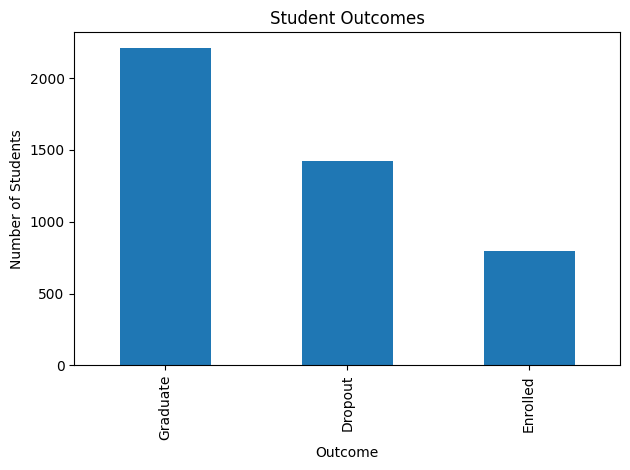

In [20]:
import matplotlib.pyplot as plt

df["Target"].value_counts().plot(kind="bar")

plt.title("Student Outcomes")
plt.xlabel("Outcome")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()

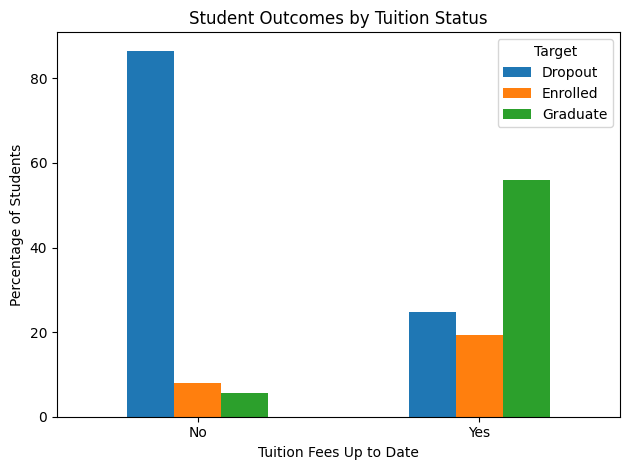

In [21]:
tuition_plot = pd.crosstab(
    df["Tuition fees up to date"],
    df["Target"],
    normalize="index"
).mul(100)

tuition_plot.plot(kind="bar")

plt.title("Student Outcomes by Tuition Status")
plt.xlabel("Tuition Fees Up to Date")
plt.ylabel("Percentage of Students")
plt.xticks([0, 1], ["No", "Yes"], rotation=0)
plt.tight_layout()
plt.show()

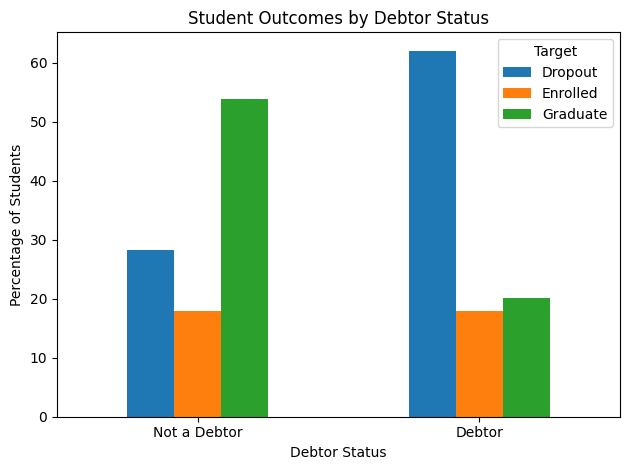

In [22]:
debtor_plot = pd.crosstab(
    df["Debtor"],
    df["Target"],
    normalize="index"
).mul(100)

debtor_plot.plot(kind="bar")

plt.title("Student Outcomes by Debtor Status")
plt.xlabel("Debtor Status")
plt.ylabel("Percentage of Students")
plt.xticks([0, 1], ["Not a Debtor", "Debtor"], rotation=0)
plt.tight_layout()
plt.show()

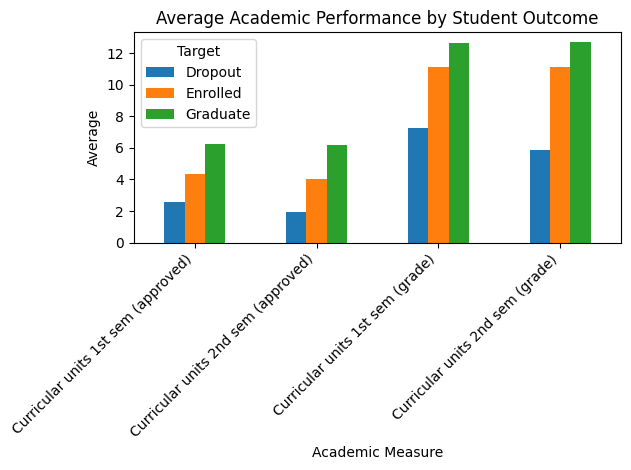

In [23]:
academic_comparison.T.plot(kind="bar")

plt.title("Average Academic Performance by Student Outcome")
plt.xlabel("Academic Measure")
plt.ylabel("Average")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [24]:
plt.savefig("chart_name.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>